* **Full Name:** Alessio Arcara
* **Institutional Email:** alessio.arcara@studio.unibo.it
* **Student ID:** 0001147867

---

## Table of Contents
0. [Setup and Imports](#0-setup-and-imports)
1. [Introduction](#1-introduction)
2. [Dataset](#2-dataset)
3. [Proposed Methodology](#3-proposed-methodology)
    * 3.1 [Latent Space Shaping for OOD Detection](#3.1-latent-space-shaping-for-ood-detection)
    * 3.2 [Network Architecture](#3.2-network-architecture)
    * 3.3 [Training Objectives](#3.3-training-objectives)
    * 3.4 [Anomaly Identification Criterion](#3.4-anomaly-identification-criterion)
    * 3.5 [Training Recipe](#3.5-training-recipe)
        * 3.5.1 [Data Augmentations](#3.5.1-data-augmentations)
4. [The Baseline Model](#4-the-baseline-model)
5. [Ablation Study](#5-ablation-study)
    * 5.1 [Encoders](#5.1-encoders)
    * 5.2 [Decoders](#5.2-decoders)
    * 5.3 [Contrastive Losses](#5.3-contrastive-losses)
    * 5.4 [Combo Losses](#5.4-combo-losses)
    * 5.5 [Anomaly Identification Criteria](#5.5-anomaly-identification-criteria)
6. [The Optimized Model](#6-the-optimized-model)
7. [Comparison and Discussion](#7-comparison-and-discussion)
8. [References](#8-references)

---

## 0. Setup and Imports

In [4]:
%load_ext autoreload
%autoreload 2
import sys

from loguru import logger

from ml4cv_assignment.config.config import StreetHazards
from ml4cv_assignment.config.utils import build_config
from ml4cv_assignment.utils.misc import fix_random

# Suppress loguru info logs
logger.remove()
logger.add(sys.stderr, level="ERROR")

fix_random(42)

## 1. Introduction

This work is situated within the field of **Anomaly Segmentation**, defined as the ability of a model to segment anomalies in an image, i.e., objects that do not belong to the classes seen during training. This task is critical in domains such as industrial inspection (e.g., defect detection on products) and autonomous driving (e.g., detecting unexpected objects such as animals crossing the road). Consequently, the problem involves a dual objective: maintaining high performance on **closed-set segmentation** (segmenting known classes) while also achieving robust **open-set segmentation** (identifying anomalies).

Specifically, I have investigated **contrastive learning** approaches, which aim to structure the latent space to create a well-defined logit space. In this space, pixels corresponding to known classes (**Known Classes - KC**) are distinctly separated from those corresponding to unknown classes (**Unknown Classes - UC**).

<div style="text-align: center;">
    <img src="../assets/both.png" width="50%"/>
</div>

To provide a comprehensive evaluation, I have also implemented a **mask-classification** approach based on **Mask2Former** with an anomaly segmentation component. As Mask2Former represents the current SOTA, it serves as a benchmark to assess the effectiveness of the proposed approach. 

Guided by these implementations, I seek to answer the following questions:
* How does the proposed contrastive learning approach compare to other contrastive approaches found in the literature?
* Can the proposed contrastive learning approach compete with SOTA methods based on Mask Classification?

## 2. Dataset

This work utilizes the **StreetHazards** dataset, a benchmark designed for anomaly segmentation. It has been generated using a modified version of the CARLA simulator, which allows for the creation of **synthetic images** with precise ground truth annotations for every pixel. The dataset simulates a *vehicle navigating through various urban environments*. The dataset is divided into three subsets: training, validation, and test sets, with anomalies present only in the test set.

Before detailing the methodology, it's essential to analyze the dataset's characteristics to understand the specific challenges it presents and the solutions designed to tackle them.

In [3]:
from ml4cv_assignment.data.data_analysis import (
    analyze_dataset,
    browse_dataset,
    compute_class_heatmap,
    plot_class_counts,
    plot_class_heatmaps,
    plot_rgb_means,
)

cfg, _ = build_config(["../configs/data_analysis.yaml"])

train_ds = cfg.train_dataset
val_ds = cfg.val_dataset
id_to_label_map = train_ds.id_to_label_map()

print(f"Number of training images: {len(train_ds)}")
print(f"Number of validation images: {len(val_ds)}")

2025-12-13 00:10:56.444 | INFO     | ml4cv_assignment.config.utils:_get_experiment_config:36 - 📄 Building config from 1 files:
2025-12-13 00:10:56.444 | INFO     | ml4cv_assignment.config.utils:_get_experiment_config:39 -     -> Loading: data_analysis.yaml
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
2025-12-13 00:10:56.759 | INFO     | ml4cv_assignment.data.data_utils:__init__:43 - Serialized dataset takes 0.00 MiB
2025-12-13 00:10:56.779 | INFO     | ml4cv_assignment.data.data_utils:__init__:43 - Serialized dataset takes 0.00 MiB
2025-12-13 00:10:56.784 | INFO     | ml4cv_assignment.data.data_utils:__init__:43 - Serialized dataset takes 0.00 MiB
2025-12-13 00:10:56.788 | INFO     | ml4cv_assignment.data.data_utils:__init__:43 - Serialized dataset takes 0.00 MiB


Number of training images: 5125
Number of validation images: 1031


In [3]:
train_ds_stats = analyze_dataset(train_ds)
val_ds_stats = analyze_dataset(val_ds)

Analyzing dataset: 100%|██████████| 1031/1031 [01:06<00:00, 15.56img/s]


In [22]:
print(f"Image sizes in train set: {train_ds_stats.image_sizes}")
print(f"Image sizes in val set: {val_ds_stats.image_sizes}")

Image sizes in train set: {(720, 1280)}
Image sizes in val set: {(720, 1280)}


The images in the training and validation sets have the **same size**; however, their format is **rectangular rather than square**.
Since most pretrained models are trained on square-shaped inputs (e.g., 224x224), maintaining a consistent input shape with the original training setup is important.

Simply resizing the rectangular images to a square format could introduce **distortion**, potentially altering object proportions and affecting model performance.

A possible solution is to apply **letterbox padding** to make the images square without distortion.
Alternatively, the inconsistent dimensions can be ignored, and the images can be fed to the model in their rectangular format, provided the architecture supports variable input sizes.

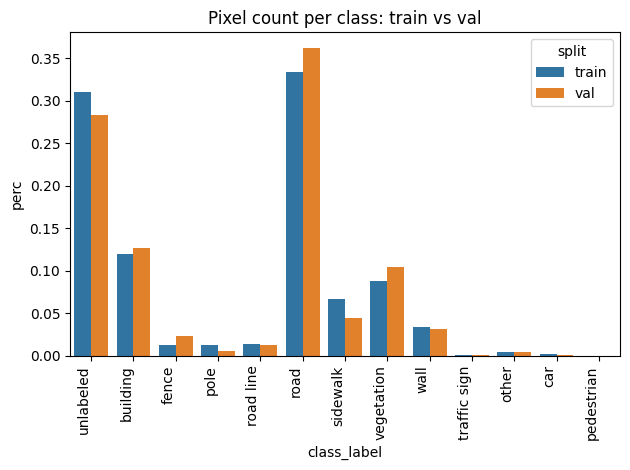

In [23]:
plot_class_counts(
    train_ds_stats.pixel_counts, val_ds_stats.pixel_counts, id_to_label_map, "Pixel"
)

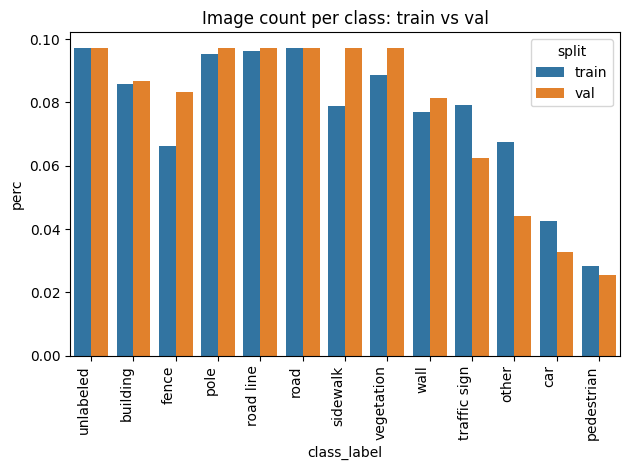

In [24]:
plot_class_counts(
    train_ds_stats.image_counts, val_ds_stats.image_counts, id_to_label_map, "Image"
)

The pixel count and image count distributions between the training and validation sets are overall similar, indicating that the two splits are consistent in term of class representation.

However, the **pixel count distribution reveals a strong class imbalance**.  This is likely due to both the **size of objects** in the images and their **lower frequency of occurrence**. For example, classes like _road_ and _unlabeled_ (sky) cover large portions of the frame, while smaller objects such as _traffic signs_ and _pedestrians_ occupy fewer pixels and appear in fewer images.

This imbalance suggest the benefit of using focal loss or class weighting strategies during training to mitigate the bias toward majority classes.

In [25]:
print("Training set mean per channel (R, G, B):", train_ds_stats.rgb_means.mean(axis=0))
print("Training set std per channel (R, G, B):", train_ds_stats.rgb_stds.mean(axis=0))
print("Validation set mean per channel (R, G, B):", val_ds_stats.rgb_means.mean(axis=0))
print("Validation set std per channel (R, G, B):", val_ds_stats.rgb_stds.mean(axis=0))

Training set mean per channel (R, G, B): [0.3307164  0.34626445 0.37320235]
Training set std per channel (R, G, B): [0.1615142  0.15994391 0.17404957]
Validation set mean per channel (R, G, B): [0.33165857 0.34048793 0.35836303]
Validation set std per channel (R, G, B): [0.16222227 0.15592927 0.16400203]


/home/aarcara/ml4cv_assignment/ml4cv_assignment/data/data_analysis.py:142: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


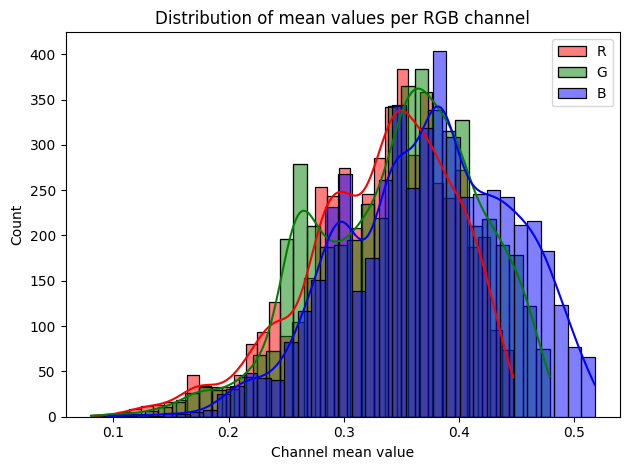

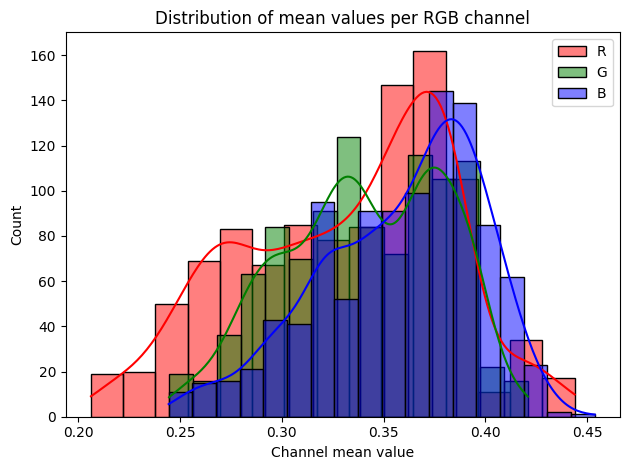

In [26]:
plot_rgb_means(train_ds_stats.rgb_means)
plot_rgb_means(val_ds_stats.rgb_means)

The fact that all values are below 0.5 suggests that the images contain **predominantly gray regions**, which is consistent with a street-driving dataset due to the **strong presence of asphalt and buildings**.

The **higher presence of blue likely indicates many areas of sky**, which is also in line with an street-driving dataset.

Both the training and validation sets show similar color distributions, as well as comparable dynamic variation.

The distributions are **mesocurtic**, showing significant variance. This suggests that the dataset contains images with a wide range of lighting conditions, from bright scenes under direct sunlight to darker scenes in shadow or on cloudy days.

In the validation set, the green (G) channel distribution is **shifted to the right** relative to the red (R) channel, whereas in the training set they were nearly overlapping, suggesting a potential **data shift**.

In [27]:
train_class_heatmap = compute_class_heatmap(train_ds)
val_class_heatmap = compute_class_heatmap(val_ds)

Computing heatmap: 100%|██████████| 1031/1031 [00:33<00:00, 30.36img/s]


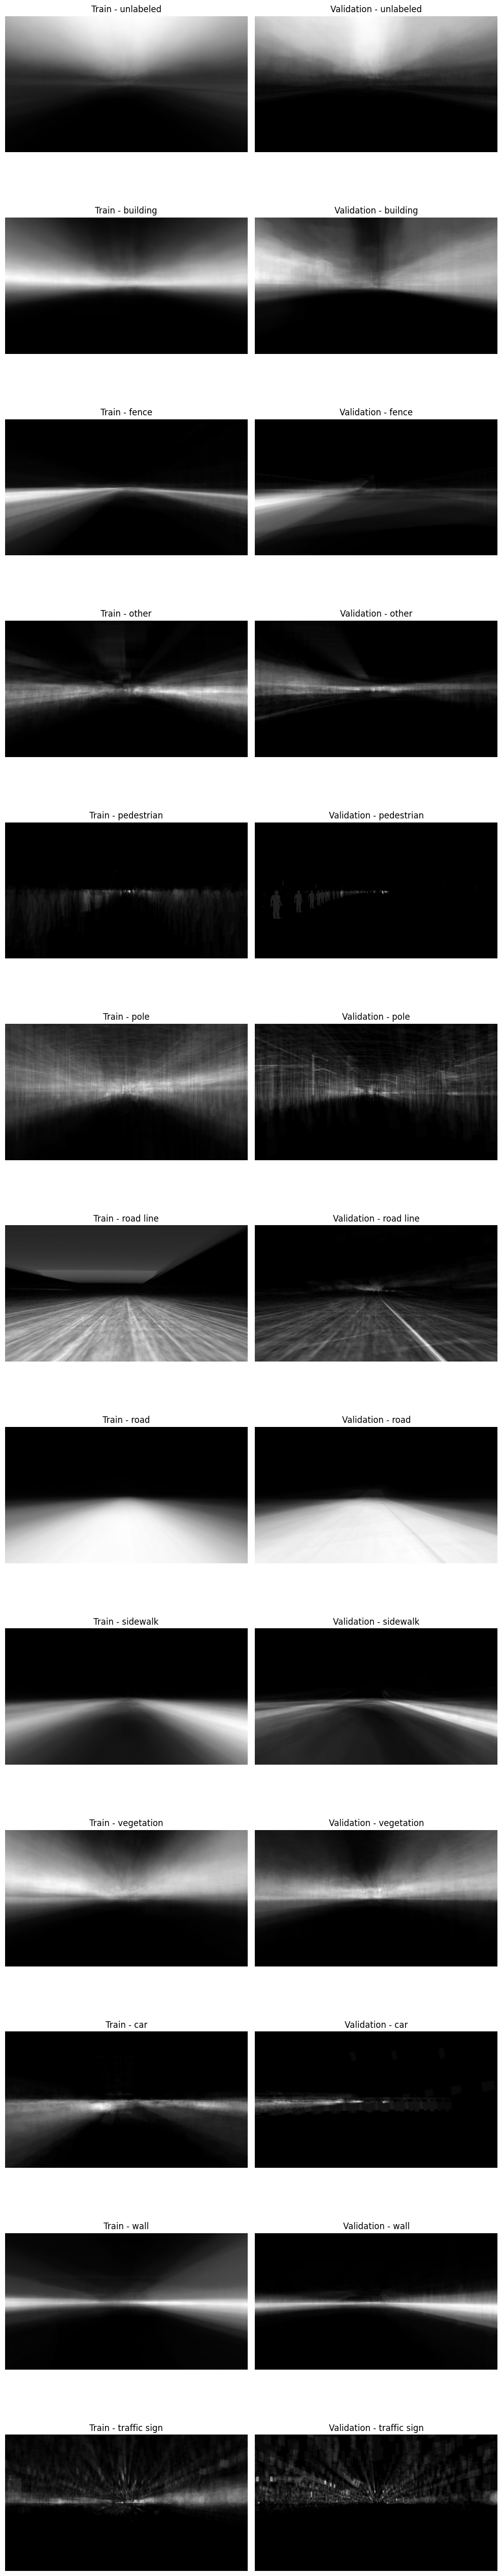

In [28]:
plot_class_heatmaps(train_class_heatmap, val_class_heatmap, id_to_label_map)

Those are the spatial distributions of each class calculated over all images of the training and validation datasets. Brighter areas indicate a higher frequency of appearance.

Some objects consistently appear in certain parts of the images: the sky is always at the top, the road is always at the bottom, sidewalks and pedestrians are on or alongside the road (they don't float in the sky). Cars are on the road, and so on.

Attention is therefore needed when applying geometric data augmentation so as
**not to break the "world rules"**, preserving these useful spatial biases and avoiding negative impacts on model performance.

If the spatial priors between training and validation were not aligned, more aggressive data augmentation could have been applied.

In [32]:
browse_dataset(train_ds)

interactive(children=(IntSlider(value=0, description='Index:', max=5124), Output()), _dom_classes=('widget-int…

In [33]:
browse_dataset(val_ds)

interactive(children=(IntSlider(value=0, description='Index:', max=1030), Output()), _dom_classes=('widget-int…

The dataset shows **significant variability in weather conditions**, including sunny and rainy days. As a result, it contains challenging situations such as reflections, glare, and variations in color distribution during sunrise and sunset, which could suggest the use of data augmentations to handle these situations and improve generalization.

Moreover, the dataset contains **sequential frames**, which can impact the model due to dependencies between samples in a batch, suggesting the need to shuffle the training set.

Finally, there is some **ambiguity** in the labeling. For example, some objects belonging to buildings or other structures end up in the **"unlabeled" category along with the sky**. This ambiguity could affect the model, as similar pixels may have different labels (e.g., one building labeled correctly and another considered unlabeled).

## 3. Proposed Methodology

### 3.1 Latent Space Shaping for OOD Detection

As previously discussed, the goal is to construct a **well-behaved logit space** in which the Known Classes (KC) form compact, well-separated clusters, while Unknown Classes (UC) are kept at a distance from these clusters. If one uses a standard cross-entropy loss, the resulting latent geometry is known to become **star-shaped**, with classes arranged radially around the origin. This structure is suboptimal for OOD detection because UC embeddings often fall near KC regions, leading to misclassification.

To enforce compact clusters for the KCs, **a contrastive loss has therefore been adopted**, which naturally encourages intra-class compactness and inter-class separation. Once this structure is established, **distance-based scoring functions** in the latent space can be used to reliably identify UC pixels.

A possible strategy would be to learn a prototype for each KC—for example, using moving averages of pixel embeddings. However, it has been shown that learned prototypes can be unstable, since they continuously shift during training. To avoid this issue, an alternative approach is followed: **fixed class centroids are assigned**, aligned with the canonical basis vectors and scaled by a magnitude $T$. That is, the centroid for class $i$ is the vector

$$
(T,0,\ldots,0),\quad (0,T,\ldots,0),\quad \ldots
$$

This design ensures that the centroids remain **orthogonal, maximally separated**, and **static** throughout training, eliminating prototype drift. The contrastive loss therefore consistently pulls KC embeddings toward these fixed points on a hypersphere of radius $T$.

Additionally, following [Sodano *et al.*](https://arxiv.org/pdf/2403.07532), **the Objectosphere loss has been incorporated**, which encourages UC embeddings to have **low feature magnitude**, effectively pulling them toward the origin. This creates a clear geometric structure: KC clusters lie near their fixed centroids on the hypersphere, while UC embeddings concentrate near the center.

For pixel classification, a pixel is assigned the KC corresponding to the **maximum logit**. However, if its embedding has a norm **below a threshold $D$**, indicating that it is close to the origin, it is instead classified as **anomalous**.

Below is a schematic representation of the desired latent space geometry:

<div style="text-align: center; background-color: #f9f9f9; padding: 10px;">
    <img src="../assets/ood_methodology.png" width="25%"/>
</div>

### 3.2 Network Architecture 

Concerning the architecture of the network, the starting point was a DeepLabV3+ model, which was then modified in various ways to improve closed-set segmentation performance. 

It leverages the **Timm library** to easily select pre-trained encoders, specify stride with dilation, and choose activation maps. I utilize an EfficientNet B2 encoder with stride 8 and extract feature maps from **stages 1, 4, and the stem output**. The dilated convolutions increase the receptive field without losing spatial resolution, which is crucial for semantic segmentation.

Then the high-level feature map (stage 4) is passed through an **ASPP module** to capture multi-scale context from the encoded features. However, instead of relying on standard atrous rates (e.g., 6, 12, 18), the atrous rates are calculated based on the input resolution, following the findings from the paper [Resolution-Aware Design of Atrous Rates for Semantic Segmentation Networks](https://arxiv.org/pdf/2307.14179).

In fact, standard atrous rates can be suboptimal if they exceed the feature map size (degenerating to a 1x1 convolution) or are too small (failing to capture global context). Therefore, the atrous rates are computed using the formula:

$$r^*=\text{round}(\frac{l}{6s})$$

where $l$ is the input size and $s$ is the output stride. This ensures that effective receptive field are appropriately scaled to the input resolution.

Successively, the features maps are fused using a **[FaPN (Feature-aligned Pyramid Network)](https://arxiv.org/pdf/2108.07058)** to recover spatial details lost during encoding. I discovered it reading the MaskFormer paper, where it was mentioned that they used it as pixel decoder, and I ported the implementation from detectron2.

I chose FaPN over a classic FPN because it promises to better align feature maps of different semantic levels and improve precision around object boundaries. In fact, feature misalignment arises from downsampling operations, and simple fusion methods (via addition or concatenation) lose important details around object edges. The **Feature Alignment Module (FAM)** learns 2D spatial offsets to realign the upsampled feature maps with lower-level ones. It uses **deformable convolutions** to sample the feature maps at non-fixed grid positions, which are learned during training.

The paper reports improvements of 1-3% in mIoU compared to FPN across various semantic segmentation datasets, especially for small objects.

The FaPN also includes a **Feature Selection Module (FSM)** to emphatize low-level features that have rich spatial detail but often contain excessive noise. This is similar to Squeeze-and-Excitation (SE), but with an added skip connection between the input and the scaled features to prevent over-filtering or over-emphasizing low-level features. While both modules recalibrate the feature maps, FSM is designed for the neck, whereas SE is often used within encoders.

Compared to DeepLab I chose to also fuse the output of the **stem**, which contains the best spatial details. Therefore, the network, through the use of FaPN and the stem output, may allow for better recovery of spatial details.

Below is a schematic representation of the architecture.

<div style="text-align: center; background-color: #f9f9f9; padding: 10px;">
    <img src="../assets/proto_segnet_arch.png" width="70%"/>
</div>

### 3.3 Training Objectives

To achieve the objectives outlined in section 3.1, the following training pipeline is utilized:

1. **Closed-Set Metric Learning**: The first stage performs closed-set training using a contrastive loss to position KCs compactly and close to fixed centroids on a hypersphere of radius $T$ along the axes of the canonical basis.
2. **Open-Set Supervision via Outlier Exposure**: Once the closed-set training is completed, a second training phase is introduced to handle the open-set part. Following the widely adopted practice in the literature, this stage  applies supervision to UKs through **outlier exposure**, in which objects from an external dataset (specifically COCO in this work) are injected during training and labeled as anomalies.

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


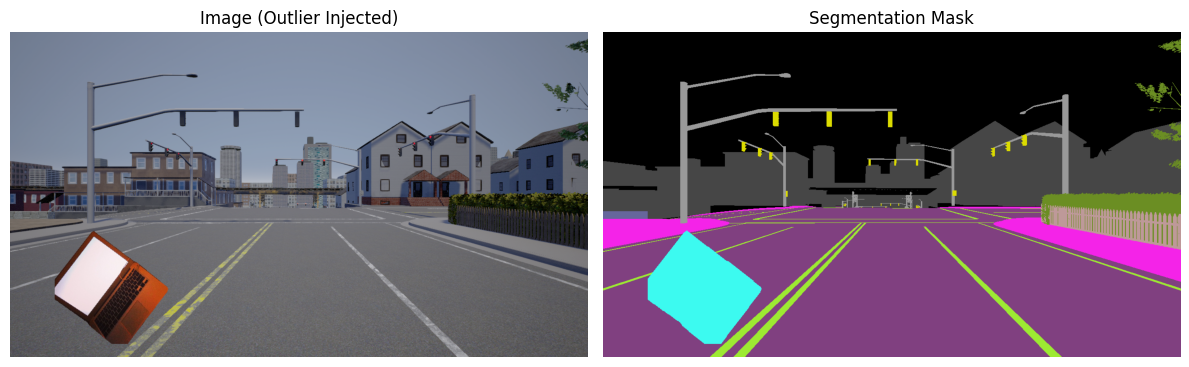

In [8]:
from ml4cv_assignment.utils.visualize import show_injected_outlier

cfg, _ = build_config(
    ["../configs/data_analysis.yaml"],
    overrides={"dataset_config": {"add_anomalies": True, "prob_insert": 1.0}},
)

show_injected_outlier(cfg.train_dataset[0])

For the contrastive loss, the **Prototypical Triplet Loss** from the paper [A Prototypical Metric Learning Approach for Open-Set Semantic Segmentation on Remote Sensing Images](https://ieeexplore.ieee.org/document/10669600) has been chosen. This loss has proven to be the best and most stable among those tested in the literature for this task. It is designed to address challenges in semantic segmentation such as class imbalance (small objects) and uncertainty at class boundaries. Boundary uncertainty is critical for open-set segmentation, as uncertain pixels may be misclassified as anomalies. Therefore, having a loss that helps reduce this uncertainty is crucial.

This loss works directly on the *confusion matrix* to perform triplet mining, which is very efficient since pixel-wise mining would be computationally prohibitive, and random sampling would not guarantee convergence. The loss has two specific terms:

* **Global Triplet Loss**: This term operates at the batch level. It pulls True Positives (Positives) toward the centroids (Anchors) of their respective classes, while pushing False Positives (Negatives) away from each centroid/anchor. It aims to build compact, well-separated clusters for all known classes in the latent space. The global loss is computed for each class independently and then averaged over all classes. This ensures that all classes contribute equally to the loss, preventing majority classes from dominating.
* **Local Triplet Loss**: While the global term handles overall class separation, the local term operates at the image level, focusing on difficult pixels near class boundaries. Here, the anchors are the True Positives (anchors), False Negatives (positives), and False Positives (negatives). 

During training, the global triplet term typically dominates early on due to larger distances, but as training progresses, the local triplet term becomes more significant, helping refine boundaries and reduce uncertainty.

<div style="text-align: center; padding: 10px;">
    <img src="../assets/prototypical_triplet_loss.png" width="40%"/>
</div>

For the open-set supervision, following Sodano et al., the [Objectosphere Loss](https://arxiv.org/pdf/2311.00400) has been chosen. It minimizes the feature magnitude of UC embeddings (pushing them toward the origin), while pushing KC embeddings bigger than a threshold $\xi$.

The loss is defined as follows:
$$
\mathcal{L}_{\text{obj}} = \begin{cases} 
\max \left( \xi - \| \boldsymbol{f}_p \|^2, 0 \right) & , \text{if } p \in \mathcal{D}_{in} \\
\| \boldsymbol{f}_p \|^2 & , \text{otherwise}
\end{cases} \tag{9}
$$
where $f_p$ is the feature embedding of pixel $p$, $\mathcal{D}_{in}$ is the set of pixels belonging to known classes and $\xi$ is a margin hyperparameter.

To further enhance segmentation performance, I also incorporated **Dice Loss**. As highlighted in [Loss Functions in the Era of Semantic Segmentation: A Survey and Outlook](https://arxiv.org/html/2312.05391v1), Dice Loss is particularly effective at avoiding local minima. In my experiments, this loss proved to be essential for driving the optimization process when other losses plateaued.

The resulting total losses for closed-set and open-set training are therefore:
$$\mathcal{L}_{closed}=\mathcal{L}_{\text{ptl}}+\mathcal{L}_{\text{dice}}$$
$$\mathcal{L}_{open}=\mathcal{L}_{\text{ptl}}+\mathcal{L}_{\text{dice}}+\mathcal{L}_{\text{obj}}$$

While my methodology is heavily inspired by the findings of Sodano et al., there are key structural differences:

| Aspect                       | Sodano et al.                   | My Approach               | Advantage                                                   |
| ---------------------------- | ------------------------------- | ------------------------- | ----------------------------------------------------------- |
| **Prototypes**               | Learned prototypes              | Fixed centroids           | Stable and smoother convergence                             |
| **Model Architecture**       | Multi-head (segmentation + OOD) | Single-head               | Simpler, more efficient design                              |

### 3.4 Anomaly Identification Criterion

Once the latent space has been constructed as described in section 3.1, the next step is to exploit its geometry to identify pixels belonging to UC classes.

To decide whether a pixel is KC or UC, a combination of two scores is used: 
- **Feature-Norm Score**: measures how close the pixel embedding is to the origin,
- **Prototype Distance Score**: inspired by [Class Anchor Clustering: A Loss for Distance-based Open Set Recognition](https://arxiv.org/pdf/2004.02434), it measures the distance between the pixel embedding and the centroids of known classes. These distances are weighted by the softmin of the distances themselves, which highlights uncertainty when the embedding is similarly distant from multiple centroids.

A pixel is therefore classified as an anomaly if:
- it is projected close to the origin (low feature norm),
- it is projected far from all centroids (high absolute distance),
- or the model exhibits uncertainty between multiple centroids (high uncertainty in softmin weights).

These three possible scenarios are summarized in the figure below:

<div style="text-align: center; background-color: #f9f9f9; padding: 10px;">
    <img src="../assets/anomaly_identification_criteria.png" width="25%"/>
</div>

### 3.5 Training Recipe

All training runs were conducted at $360\times640$ resolution to maintain the rectangular aspect ratio and avoid introducing distortions associated with resizing to a square format. While this reduction in resolution negatively impacts model performance, it was necessary to ensure manageable training times. Furthermore, the lower resolution allowed for a larger batch size of 16, which benefits contrastive losses.

#### 3.5.1 Data Augmentations

I used **Albumentations**, a leading open-source library for image augmentation, to implement the augmentation pipeline. It offers a wide range of transformations, inclusing those specifically designed for street images like StreetHazards. Albumentations automatically handles bounding boxes and masks during transformations, applying the same changes to images, bounding boxes and segmentation masks.

Following the [Albumentations guidelines](https://albumentations.ai/docs/3-basic-usage/choosing-augmentations/), the augmentation pipeline is structured as follows:

- **Scale Transformations**: `Resize` or `RandomResizedCrop` are applied alternatively. This combination allows the model to learn from both localized cropped regions and full-image context, introducing scale variability and promoting **scale invariance** while maintaining alignment with the validation preprocessing.
- **Geometric Transformations**: only `HorizontalFlip` is used to preserve the spatial priors identified during dataset analysis (e.g., sky at the top, road at the bottom). Other geometric transformations such as vertical flips, rotations, or translations are avoided to maintain these priors and let the model fully leverage them.
- **Feature Diversity**: To prevent the model from over-relying on specific, fragile features for class recognition, `GridDropout` is applied. This augmentation randomly masks out pixels in a grid pattern. This forces the model to learn a more **holistic representation** of objects. 

    - For example, if a vehicle were recognized primarily by its headlights, occlusions or challenging lighting conditions affecting those areas could cause the model to misclassify it.

- **Photometric Transformations**: `ColorJitter` is used to simulate various lighting conditions and slightly alter image colors. This augments the dataset variety by simulating lighting conditions in urban areas originally photographed at only certain times of the day.

    - It is unknown whether the vehicle was captured passing through the same area multiple times at different times of day.

- **Weather Condition Simulations**: Given the dataset's variety of weather conditions (sunny, cloudy, rainy), specific augmentations are included to simulate adverse weather scenarios. These include `RandomRain` to mimic rain effects, `RandomSunFlare` to simulate sun glare and reflections, and `RandomShadow` to create shadows that could be cast by poles or the sun's position. These augmentations are used to improve model robustness under such environmental conditions.
- **Normalization**: Finally, images are normalized using the mean and standard deviation calculated from the StreetHazards training set. Using dataset-specific statistics may lead to better performance compared to using generic statistics from datasets like ImageNet.

Following the two-stage training strategy commonly used in detection, all augmentations were **disabled during the open-set finetuning phase** to better align with real-world scenarios.

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


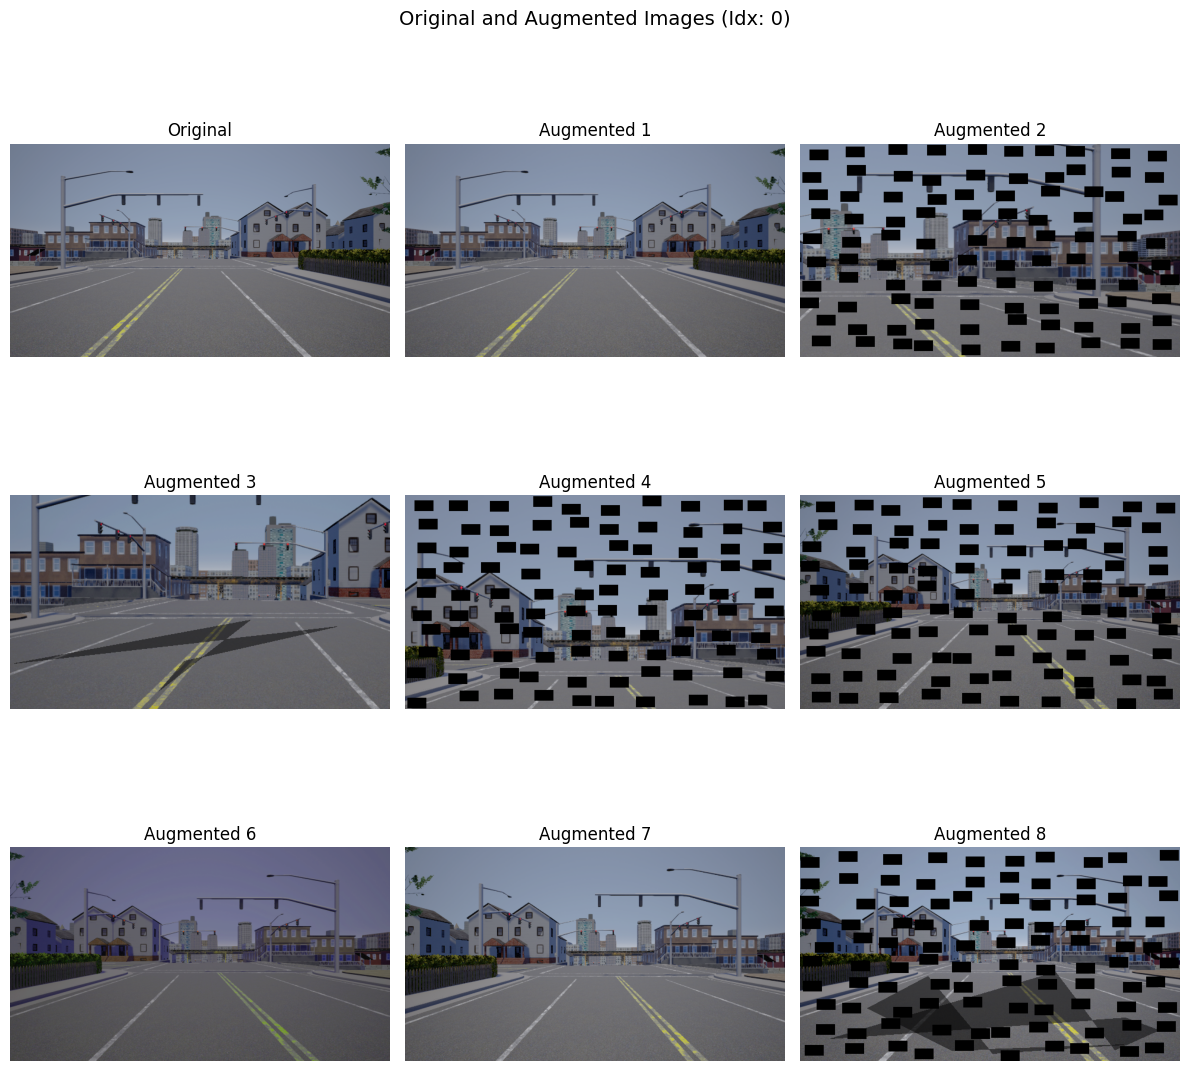

In [9]:
from ml4cv_assignment.utils.visualize import show_augmentations

cfg, _ = build_config(
    ["../configs/data_analysis.yaml", "../configs/transforms/full.yaml"]
)

show_augmentations(
    cfg.train_dataset,
    denorm=cfg.training.get_denormalize(in_train=True),
    idx=0,
    num_samples=9,
    cols=3,
)

#### 3.5.2 Implementation Details

All models were trained for 100 epochs using **mixed precision** on a single NVIDIA RTX 3090 GPU (24 GB). To prevent overfitting, **early stopping** was used


Come learning rate per il decoder è stato utilizzato 1e-3, mentre per l'encoder 1e-4 (1 decimo). Allo stesso modo il decoder ha una regolarizzazione molto più forte rispetto all'encoder. Tra closed set training e open set finetuning, il learning rate viene ridotto di un fattore 10.

per le loss closed è stato messo un ignore index per la classe unlabeled (13) in modo da non considerarla nel calcolo della loss durante la fase closed set. solo l'objectosphere lavora su di essa nella fase open set.


come learning rate scheduler è stato utilizzato OneCycleLR per favorire una più rapida convergenza, mentre come ottimizzatore AdamW, tutti gli addestramenti sono stati effettuati per 100 epoche con early stopping basato sulla mIoU della closed set sul validation set di 10 epoche e AUPR della open set di 10 epoche. All'addestramento della fase open set, è stato caricato il checkpoint migliore della fase closed set e fatto un finetuning con la tecnica di outlier exposure descritta in precedenza. Il learning rate è 0.1*base lr, dove base lr è il learning rate utilizzato nella fase closed set. Allo stesso modo l'encoder rispetto al decoder ha un learning rate 0.1*decoder lr.

gli addestramenti sono stati condotti su una singola GPU NVIDIA RTX 3090 con 24GB di memoria in mixed precision

:
drop_path_rate

for $T$ the magnitude of the centroid as 10 and $\xi$ the margin for the objectosphere as I choose 5 as highlighted in the ablation study of class centroids etc
It was highlighted that using a unit hypersphere (T=1) led to suboptimal performance, increasing T to 10 provided more separation between classes and improved OOD detection. Similarly, setting the Objectosphere margin $\xi$ to 5 created a clear boundary between KC and UC embeddings, increasing anomaly identification.



## 4. The baseline model

dimensione della rete

### 4.1 Metrics

to evaluate the model..
il modello finora spiegato verrà valutato sul validation set, che rappresenta il baseline model per gli studi successivi, questo modello 
sotto un processo rigoroso di esaminazione di ogni componente si è sem

mostro ora il modello per ora spiegato sul validation set, che rappresenta il baseline model per gli studi successivi, questo modello
numero parametri

analisi quantitativa e qualitativa

spiegare che verrà utilizzato come metriche per analisi quantitativa mIoU per closed set e AUPR per open set



In [5]:
cfg, _ = build_config(
    [
        "../configs/base.yaml",
        "../configs/transforms/full.yaml",
        "../configs/proto_segnet.yaml",
        "../configs/ood_proto_segnet.yaml",
    ],
    overrides={
        "dataset_config": {"add_anomalies": True, "prob_insert": 1.0},
        "paths": {
            "street_hazards_train_dir": "../datasets/train",
            "street_hazards_test_dir": "../datasets/test",
            "coco_data_dir": "../datasets/coco",
            "checkpoint": "../checkpoints/ood_baseline_proto_segnet_20251213_052614_val-OoDAUPR_epoch_0.7577.pth",
        },
    },
)

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Evaluating val:   3%|▎         | 2/64 [00:00<00:15,  4.01it/s]/home/aarcara/ml4cv_assignment/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)


+----------------------+
| Quantitative Results |
+-----------+----------+
| Metric    |    Value |
+-----------+----------+
| mIoU      |     0.66 |
| OoDAUPR   |     0.75 |
+-----------+----------+


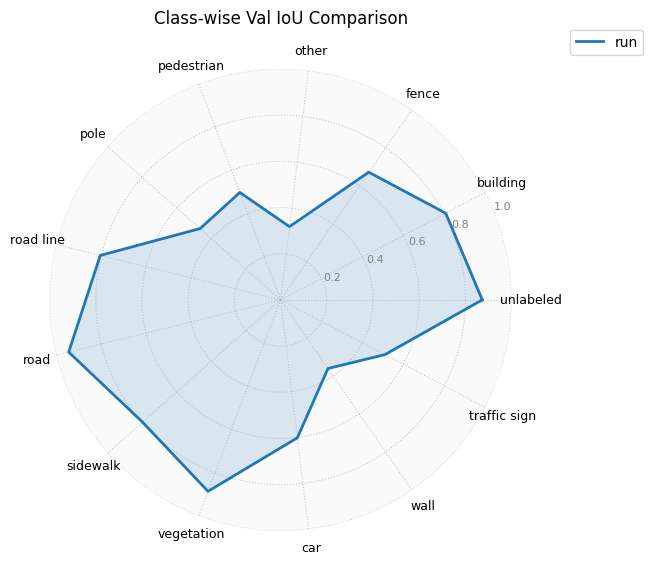

In [6]:
from ml4cv_assignment.evaluation import evaluate_split
from ml4cv_assignment.utils.visualize import show_split_results

results = evaluate_split(cfg=cfg, split="val")
show_split_results(results, StreetHazards.CLASSES)

In [ ]:
from ml4cv_assignment.utils.visualize import interactive_inference_visualizer

interactive_inference_visualizer(cfg=cfg, split="val")

## 5. Ablation Study

In [12]:
from ml4cv_assignment.utils.visualize import show_runs_comparison
from ml4cv_assignment.utils.wandb_retriever import WandBRetriever

retriever = WandBRetriever(entity="aarcara", project="ml4cv_assignment")
retriever.show_available_runs()

+----------+------------------------------------------------------+
| Run ID   | Name                                                 |
+----------+------------------------------------------------------+
| vqy4e95u | mask2former_20251123_232233                          |
| ao7qbzn9 | proto_segnet_efficientnet_b2_encoder_20251127_120255 |
| zcwl3yl4 | proto_segnet_efficientnet_b2_encoder_20251128_175827 |
| g4d7dovx | proto_segnet_convnexttiny_dinov3_20251129_001923     |
| bttuyake | proto_segnet_resnet18d_encoder_20251129_054502       |
| sc4iuq21 | proto_segnet_pvtv2_b1_20251129_093515                |
| 60229qb2 | fuse_stem_20251129_135626                            |
| ryjncr1t | fpn_20251129_175939                                  |
| t8t0bprm | no_aspp_20251129_215900                              |
| tg8vtl2y | default_atrous_rates_20251130_022321                 |
| 16v10zty | fapn_no_dilation_20251130_070940                     |
| xrvpx0vs | fpn_no_aspp_20251130_102155        

### 5.1 Encoders

For the first step of the ablation study, I analyzed the impact of the encoder choice on closed-set performance. Although [Battle of the Backbones: A Large-Scale Comparison of Pretrained Models across Computer Vision Tasks](https://arxiv.org/abs/2310.19909) finds **ResNet18d** to be the best "small" backbone for detection and segmentation tasks, I compared three different encoders: **ResNet18d**, **EfficientNet B2** and **ConvNeXt Tiny**.

The first two models are pretrained on **ImageNet**. Literature suggests that, in the absence of domain-specific pretraining (e.g., using Cityscapes for StreetHazards), initialization on ImageNet only accelerates convergence for dense tasks.

In contrast, **ConvNeXt Tiny** utilizes weights from **[DinoV3](https://arxiv.org/pdf/2508.10104)**, which were distilled from a 7B variant of ViT using a self-supervised method that has demonstrated excellent performance on dense tasks due to the semantic richness of the extracted features. Therefore, it is interesting to see if this self-supervised pretraining can bring benefits to this segmentation task as well.

+-------------------------------------------------------------+
|             Best Validation Metrics (Closed Set)            |
+------------------------------------------------------+------+
| Run                                                  | mIoU |
+------------------------------------------------------+------+
| proto_segnet_efficientnet_b2_encoder_20251128_175827 | 0.67 |
| proto_segnet_convnexttiny_dinov3_20251129_001923     | 0.65 |
| proto_segnet_resnet18d_encoder_20251129_054502       | 0.62 |
+------------------------------------------------------+------+


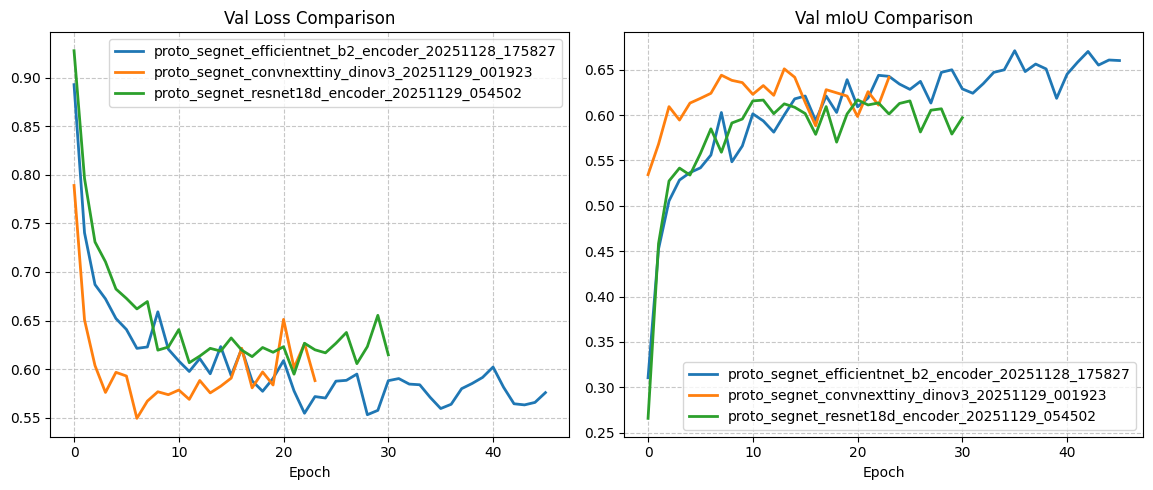

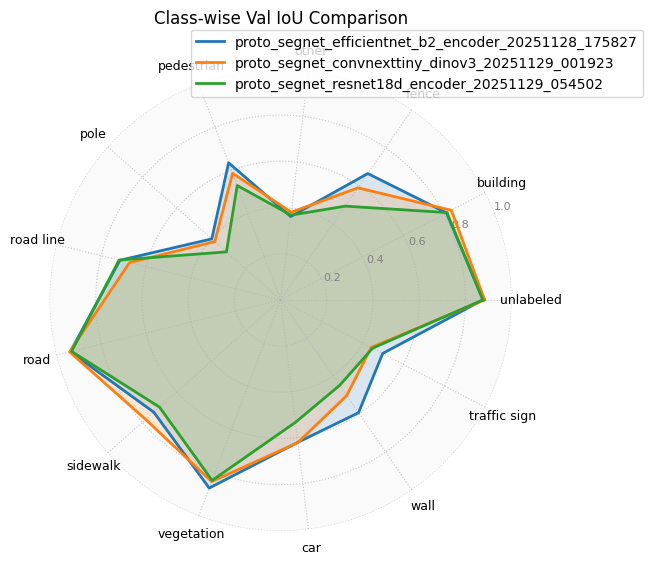

In [24]:
show_runs_comparison(
    retriever, ["zcwl3yl4", "g4d7dovx", "bttuyake"], StreetHazards.CLASSES
)

EfficientNetB2 it showed the best performance in terms of mIoU

### 5.2 Decoders

Come ablation è stato sostituito FaPN con un FPN classico, ottenenedo un aumento di mIoU, nonostante si possa osservare dalle curve che "prima o poi" FaPN avrebbe raggiunto lo stesso risultato, ma con una convergenza più lenta. Questo è probabilmente dovuto al fatto che FaPN richiede l'apprendimento di offset.

fondere l'output dello stem del backbone nella FPN si conferma la scelta migliore, con un aumento di mIoU rispetto al non farlo.

Rimuovere invece l'ASPP non risulta in un calo di prestazioni, probabilmente poichè l'addestramento con Random Scale Crop fornisce già una buona invarianza alle scale, rendendo l'ASPP superfluo. Si verificherà il comportamento anche in assenza di questo tipo di data augmentation. Questo risultato ci permette di togliere l'ASPP, riducendo il numero di parametri e la complessità computazionale del modello.

#### 5.2.1 FaPN vs FPN



#### 5.2.3 ASPP vs No ASPP

#### 5.2.2 With Stem vs Without Stem

#### 5.2.4 Dilation Rates vs No Dilation Rates

#### 5.2.5 Less channels vs More channels on decoder side

#### 5.2.6 Fuse Stem vs No Fuse Stem

#### 5.2.7 Fuse Intermediary Features vs No Fuse Intermediate Features

#### 5.2.1 FaPN vs FPN

+-------------------------------------------------------------+
|             Best Validation Metrics (Closed Set)            |
+------------------------------------------------------+------+
| Run                                                  | mIoU |
+------------------------------------------------------+------+
| proto_segnet_efficientnet_b2_encoder_20251128_175827 | 0.67 |
| fpn_20251129_175939                                  | 0.68 |
+------------------------------------------------------+------+


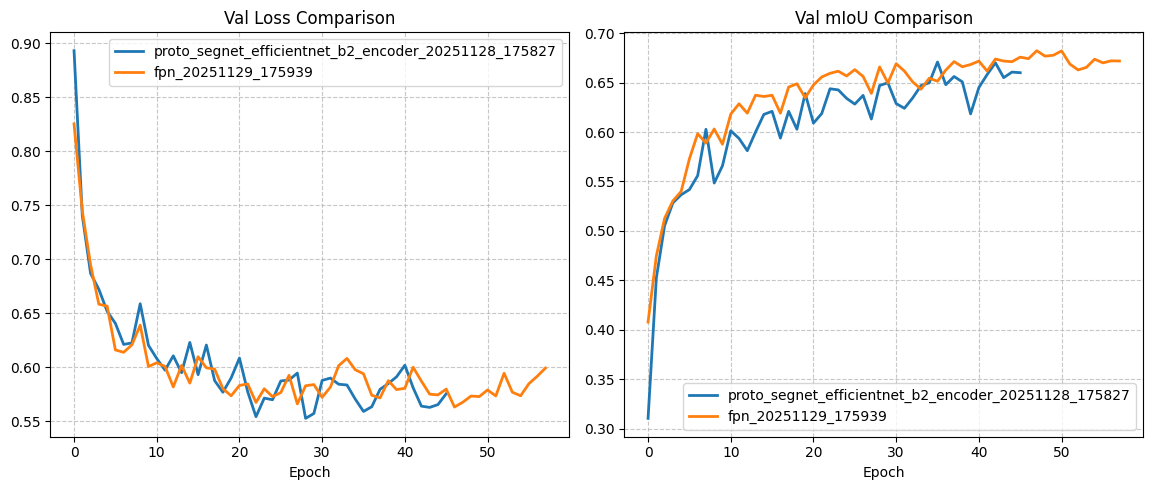

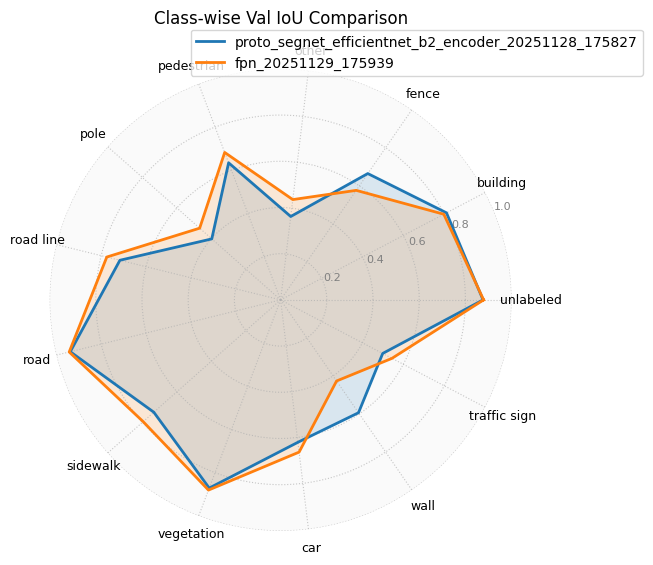

In [25]:
show_runs_comparison(
    retriever=retriever,
    run_ids=["zcwl3yl4", "ryjncr1t"],
    classes=StreetHazards.CLASSES,
    mode="closed",
)

### 5.3 Augmentations

### 5.4 Losses

#### 5.4.1 Prototypical Triplet Loss vs Other Contrastive Losses

+----------------------------------------------------+
|         Best Validation Metrics (Open Set)         |
+-----------------------------------+------+---------+
| Run                               | mIoU | OoDAUPR |
+-----------------------------------+------+---------+
| ptl_objectosphere_20251210_013021 | 0.67 |    0.77 |
| dml_objectosphere_20251211_110815 | 0.67 |    0.66 |
+-----------------------------------+------+---------+


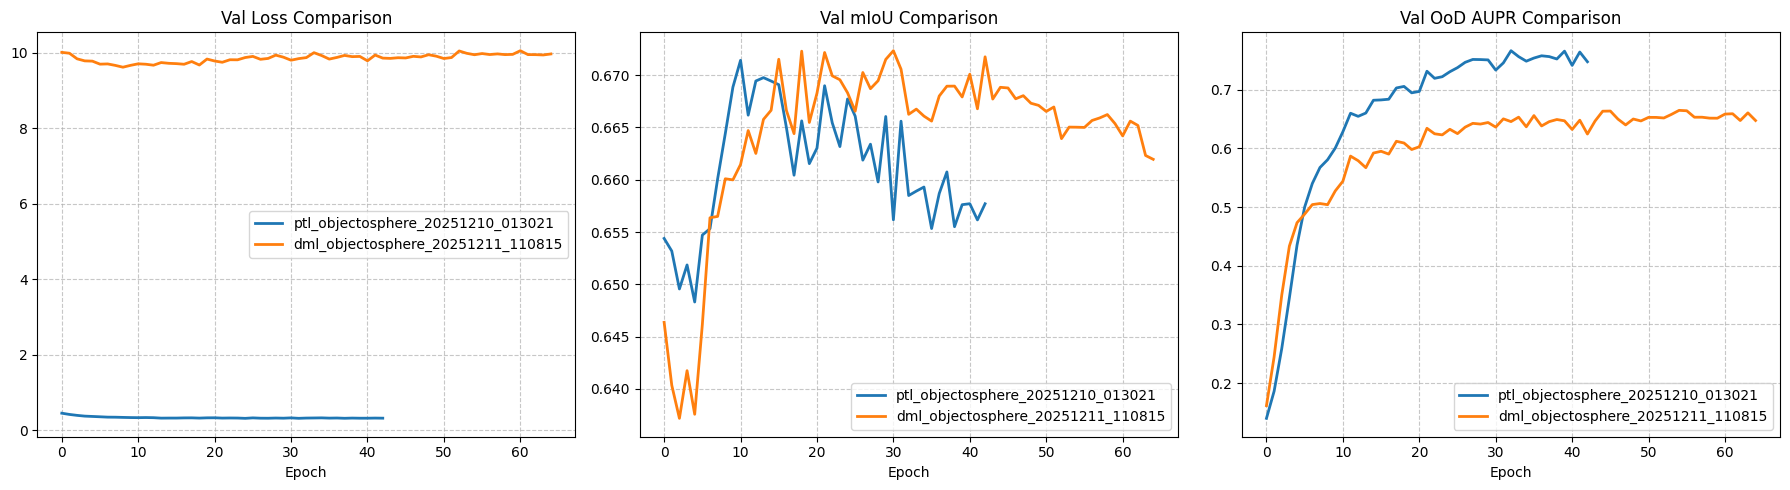

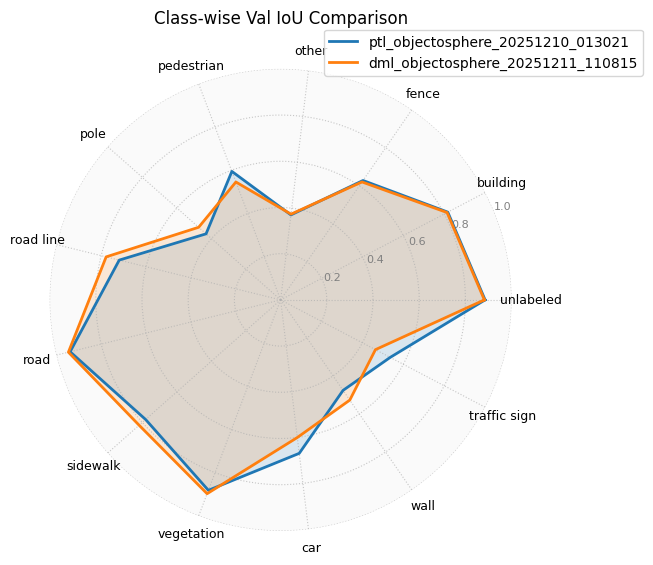

In [23]:
show_runs_comparison(
    retriever=retriever,
    run_ids=["3e8z2cx1", "vj09b8px"],
    classes=StreetHazards.CLASSES,
    mode="open",
)

#### 5.4.2 Prototypical Triplet Loss combined with other losses

+---------------------------------------------------------------+
|               Best Validation Metrics (Open Set)              |
+----------------------------------------------+------+---------+
| Run                                          | mIoU | OoDAUPR |
+----------------------------------------------+------+---------+
| ptl_objectosphere_20251210_013021            | 0.67 |    0.77 |
| ptl_dice_objectosphere_20251208_175424       | 0.68 |    0.77 |
| ptl_focal_objectosphere_20251210_060311      | 0.68 |    0.76 |
| ptl_focal_dice_objectosphere_20251210_112342 | 0.68 |    0.77 |
+----------------------------------------------+------+---------+


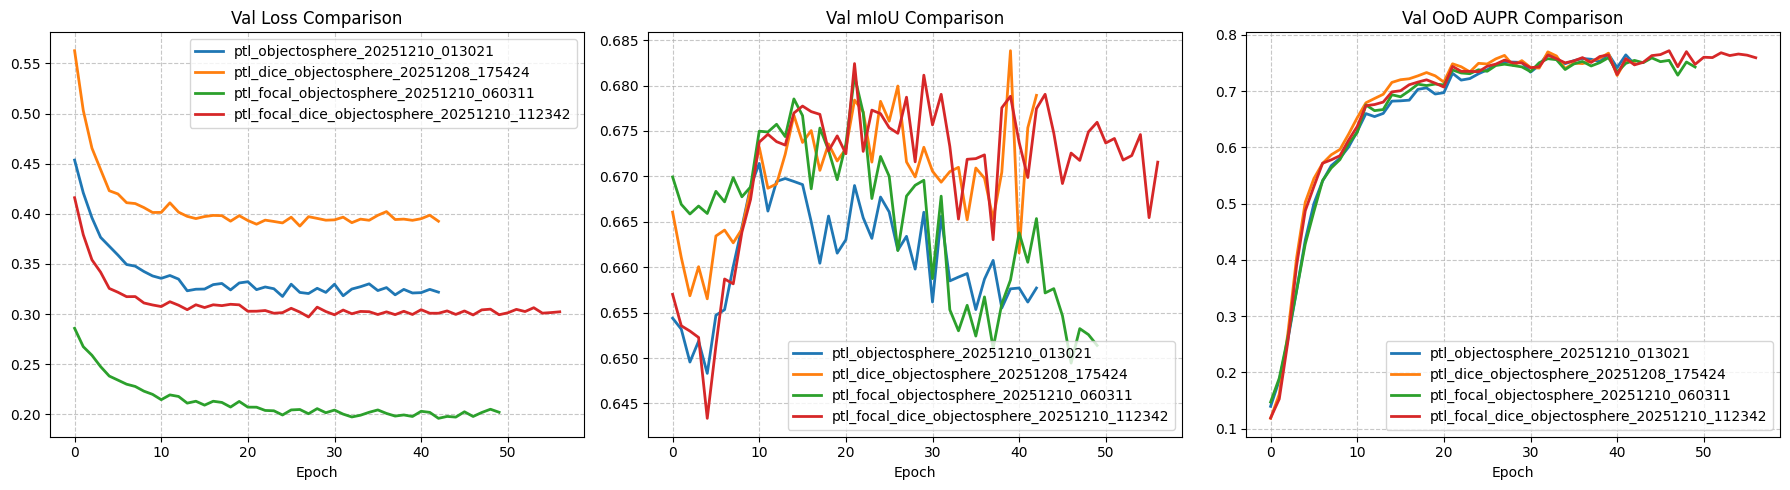

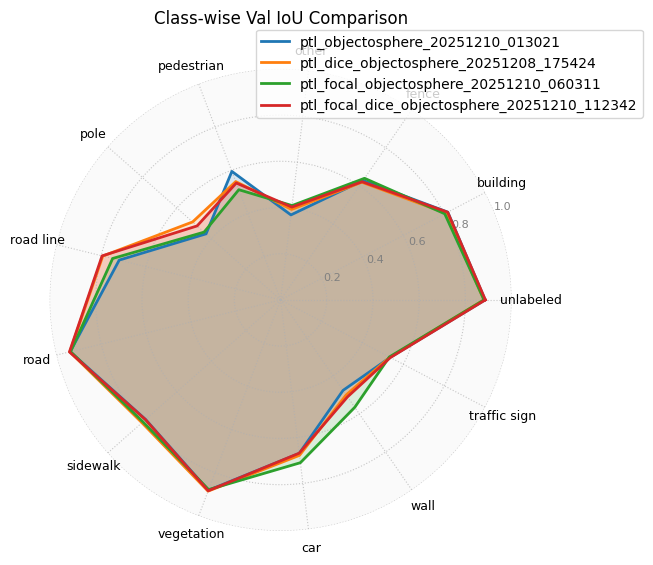

In [22]:
show_runs_comparison(
    retriever=retriever,
    run_ids=["3e8z2cx1", "rxet775k", "gazwh9hp", "wt8r9zky"],
    classes=StreetHazards.CLASSES,
    mode="open",
)

### 5.6 Anomaly Identification Criteria

## 6 The Optimized Model

il modello finale ce l'ho già

## 7. Comparison and Discussion

### 7.1 Reject by All (RbA)

Another thing that I thought lastly is when i'm finetuning with outlier exposure, should I also finetune the batch norm layers? or freeze them? 

## 6. References

* **Azad, R., Heidari, M., Yilmaz, K., et al. (2023).** Loss Functions in the Era of Semantic Segmentation: A Survey and Outlook. *arXiv preprint arXiv:2312.05391*. [Link](https://arxiv.org/abs/2312.05391)